# Train Model (EfficientNetB0)

| Step | Action | Description |
|------|-----------|-------|
| 1 | Input Stream | Capture real-time video frames from device webcam |
| 2 | PreProcessing | Resize frame and normalises pixel values |
| 3 | Stage 1: Detection (YOLOv8nY) | YOLOv8n (nano) determines and produces (output) the precise bounding box coordinates of the wire cluster |
| 4 | Cropping | Original frame is cropped to include only the wire clusters bounding box |
| 5 | Stage 2: Classification (EfficientNet-B0) | EfficientNet-B0 model processes the cropped image and classifies it (4 output neurons) |
| 6 | Decision Engine | Uses Softmax/Argmax to select one of the 4 classes |
| 7 | Final Output | Real-time display of the output class (e.g. Dangerous) and the FPS |

In [31]:
import torchvision
import torch 
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt 
import numpy as np 

In [32]:
# Point to dataset paths

train_dataset_path = '../dataset/processed/train'
test_dataset_path = '../dataset/processed/test'
val_dataset_path = '../dataset/processed/val'

In [33]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# Preprocessing pipeline for training data
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Transform and resize images
    transforms.RandomHorizontalFlip(), # Random flips
    transforms.RandomRotation(15),     # Rotate +/- 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # MIGHT REMOVE LATER, adjust brightness/contrast
    transforms.ToTensor(),             # Convert to tensor
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])

# Preprocessing pipeline for validation and test data
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),     # Transform and resize images
    transforms.ToTensor(),             # Convert to tensor
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])


In [34]:
# Create datasets
train_dataset = torchvision.datasets.ImageFolder(root=train_dataset_path, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=val_dataset_path, transform=val_test_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=test_dataset_path, transform=val_test_transforms)

In [35]:
# Load datasets into dataloaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [36]:
def set_device():
    if torch.cuda.is_available():
        dev = 'cuda:0'
    else:
        dev = 'cpu'
    return torch.device(dev)
    

In [37]:
def eval_model(model, test_loader, criterion, device):
    model.eval() # Set model to evaluation mode
    model.to(device)
    
    running_loss = 0.0
    running_corrects = 0
    total = 0
    
    # Deactivate autograd for evaluation
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Calculate how models predicts
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(predicted == labels)
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * running_corrects.item() / total

    return epoch_loss, epoch_acc


In [38]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    model.to(device) # Move model to device (GPU/CPU)

    # Initialize lists to track metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train() # Set model to training mode

        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Set gradient to zero
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Using the Cross Entropy Loss between outputs(pred) and labels(true values)

            _, preds = torch.max(outputs, 1) # Get the index of the max log-probability

            # Perform backpropagation to calculate weight gradience and optimization
            loss.backward()
            optimizer.step()
            
            # Update running loss and correct predictions
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = 100.0 * running_corrects.item() / total

        # Store train metrics
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # Validation
        val_loss, val_acc = eval_model(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        scheduler.step()
        
    print('Finished Training')
    return model, train_losses, train_accs, val_losses, val_accs


In [39]:
efficientnet_b0_model = models.efficientnet_b0(pretrained=True)
num_ftrs = efficientnet_b0_model.classifier[1].in_features
num_of_classes = 4
efficientnet_b0_model.classifier[1] = nn.Linear(num_ftrs, num_of_classes) # Modify final layer to match number of classes
device = set_device()
efficientnet_b0_model = efficientnet_b0_model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet_b0_model.parameters(), lr=0.01, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [40]:
# Start training

model, train_losses, train_accs, val_losses, val_accs = train_model(
    efficientnet_b0_model,
    train_loader,
    val_loader,
    loss_func,
    optimizer,
    scheduler,
    num_epochs=15,
    device=device
)



Epoch 1/15
Epoch 1/15 | Train Loss: 1.4461 | Train Acc: 39.16% | Val Loss: 1128.6477 | Val Acc: 14.29%

Epoch 2/15
Epoch 2/15 | Train Loss: 1.9254 | Train Acc: 34.27% | Val Loss: 919947.5000 | Val Acc: 25.00%

Epoch 3/15
Epoch 3/15 | Train Loss: 1.9810 | Train Acc: 28.67% | Val Loss: 20250.8340 | Val Acc: 25.00%

Epoch 4/15
Epoch 4/15 | Train Loss: 1.8824 | Train Acc: 28.67% | Val Loss: 2228.8496 | Val Acc: 28.57%

Epoch 5/15
Epoch 5/15 | Train Loss: 1.5479 | Train Acc: 39.16% | Val Loss: 80.0263 | Val Acc: 25.00%

Epoch 6/15
Epoch 6/15 | Train Loss: 1.3340 | Train Acc: 47.55% | Val Loss: 9.6181 | Val Acc: 46.43%

Epoch 7/15
Epoch 7/15 | Train Loss: 0.9745 | Train Acc: 52.45% | Val Loss: 2.3036 | Val Acc: 60.71%

Epoch 8/15
Epoch 8/15 | Train Loss: 1.0174 | Train Acc: 48.95% | Val Loss: 1.6826 | Val Acc: 64.29%

Epoch 9/15
Epoch 9/15 | Train Loss: 0.8999 | Train Acc: 57.34% | Val Loss: 1.6098 | Val Acc: 57.14%

Epoch 10/15
Epoch 10/15 | Train Loss: 0.8668 | Train Acc: 60.14% | Val Los

### Plot the Training Curves

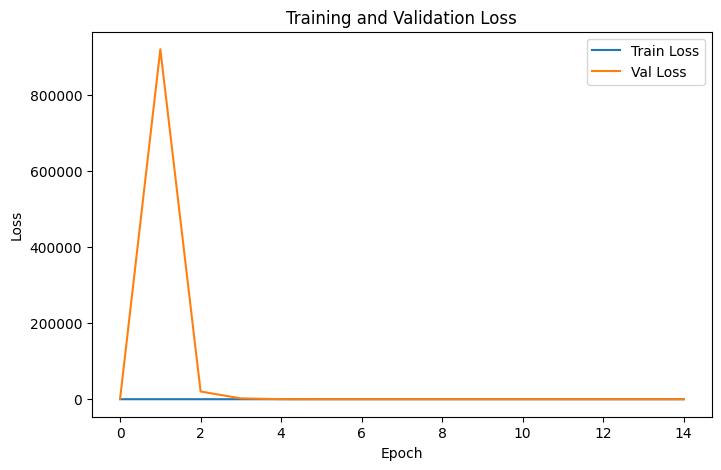

In [42]:
# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

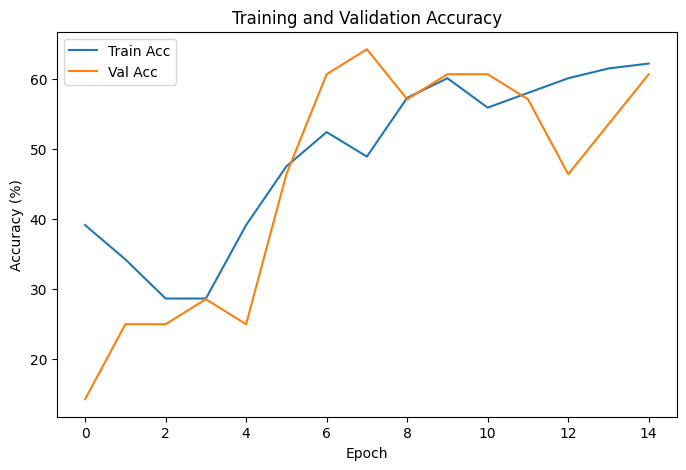

In [43]:
# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

add precision and recall